|<h2>Course:</h2>|<h1><a href="https://derivingsystems.com/course.html" target="_blank">Build your own vLLM: inference engines from the memory system up</a></h1>|
|-|:-:|
|<h2>Part 4:</h2>|<h1>The Scheduler<h1>|
|<h2>Section:</h2>|<h1>Chunked prefill<h1>|
|<h2>Lecture:</h2>|<h1><b>CodeChallenge: one token budget, two kinds of work<b></h1>|

<br>

<h5><b>Course repo:</b> <a href="https://github.com/Venugopalan2610/vllm-from-scratch" target="_blank">github.com/Venugopalan2610/vllm-from-scratch</a></h5>
<h5><b>The derivations:</b> <a href="https://derivingsystems.com" target="_blank">derivingsystems.com</a></h5>
<i>The notebooks build the intuition. The ladder in app/ makes you build the thing.</i>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

rng = np.random.default_rng(0)

Write the mixed-batch scheduler.

One token budget per step. Decoding sequences contribute one token each;
prefilling ones contribute a slice of their prompt. No step is allowed to
become a long prefill that stalls everybody.

This is stage 11, and it is the last purely logical scheduler in the course.

In [2]:
### run this cell

# 32 short conversations that arrive at once and settle into decoding,
# then at step 40 somebody pastes in 4096 tokens.
#   [arrival_step, prompt_len, output_len]
reqs = [[0, 64, 400] for _ in range(32)] + [[40, 4096, 100]]
print(f'{len(reqs)} requests; the big one arrives at step {reqs[-1][0]}')

33 requests; the big one arrives at step 40


# Exercise 1: the budget loop

Every step spends a fixed number of tokens. Decodes first, then as much of
the waiting prompts as still fits.

In [3]:
def schedule(requests, budget, max_running=64):
  """requests: [[arrival_step, prompt_len, output_len], ...].
  Returns an array of (tokens_in_step, sequences_decoding_that_step)."""
  pending = sorted(requests)
  waiting, prefilling, decoding = [], [], []
  steps, t = [], 0

  while pending or waiting or prefilling or decoding:
    while pending and pending[0][0] <= t:
      _, p, o = pending.pop(0); waiting.append([p, o])
    while waiting and len(prefilling) + len(decoding) < max_running:
      waiting_r = waiting.pop(0); prefilling.append(waiting_r)

    used = 0
    n_decoding = len(decoding)      # how many users are waiting on this step
    # decodes first: they are one token each and they are latency-critical
    for d in list(decoding):
      if used >= budget: break
      used += 1; d[1] -= 1
      if d[1] == 0: decoding.remove(d)

    # then fill whatever budget is left with prompt chunks
    for pr in list(prefilling):
      if used >= budget: break
      take = min(pr[0], budget - used)
      pr[0] -= take; used += take
      if pr[0] == 0:
        prefilling.remove(pr); decoding.append(pr)

    steps.append((used, n_decoding)); t += 1
    if used == 0 and not pending: break
  return np.array(steps)

s = schedule(reqs, budget=512)
print(f'{len(s)} steps, mean {s[:,0].mean():.0f} tokens, max {s[:,0].max()} tokens')

405 steps, mean 47 tokens, max 512 tokens


# Exercise 2: put a cost on it, in the right units

A step is not proportional to the tokens in it. Measured in
`part4_chk_theStall`, it is flat up to a couple of hundred tokens and linear
after that, and where the bend falls is a property of your card.

So do not write milliseconds down. Write the cost in **units of one plain
decode step**, with the bend as a parameter. Then every number below is a
ratio, and Exercise 3 can change the machine without changing anything else.

In [4]:
# Step cost is not a table of milliseconds. It is Part 1's roofline again:
# a step is free up to KNEE tokens and linear after that.
#
#     cost(n) = max(1, n / KNEE)          in units of a plain decode step
#
# KNEE is the only hardware number in this notebook. Measure yours in
# part4_chk_theStall: the largest token budget whose step still costs what a
# 32-token step costs.
KNEE = 256

def step_cost(n):
  """Cost of a step holding n tokens, in units of one plain decode step."""
  return max(1.0, n / KNEE)

print(f"{'budget':>7} {'steps':>7} {'total cost':>11} {'p99 ITL':>9} {'worst ITL':>11}")
for budget in (64, 128, 256, 512, 1024, 4096):
  s   = schedule(reqs, budget)
  c   = np.array([step_cost(x) for x in s[:,0]])
  # every decoding sequence waited this step out. THAT is the population.
  itl = np.repeat(c, s[:,1].astype(int))
  print(f'{budget:>7} {len(s):>7} {c.sum():>10.0f}x {np.percentile(itl,99):>8.2f}x '
        f'{itl.max():>10.2f}x')
print('\nall costs are multiples of one plain decode step')

 budget   steps  total cost   p99 ITL   worst ITL
     64     444        444x     1.00x       1.00x
    128     419        419x     1.00x       1.00x
    256     409        409x     1.00x       1.00x
    512     405        417x     2.00x       2.00x
   1024     403        421x     4.00x       4.00x
   4096     401        423x     1.00x      16.00x

all costs are multiples of one plain decode step


# Exercise 3: change the machine

Everything above used one `KNEE`. Sweep it and find the best budget for each
machine. You are looking for a rule relating the two, not three numbers.

  KNEE      64     128     256     512    1024    2048    4096
    64     444     480     489     493     494     494     495   best budget 64
   256     444     419     409     417     421     422     423   best budget 256
  1024     444     419     409     405     403     404     405   best budget 1024


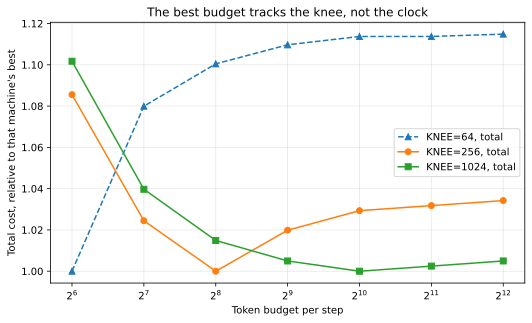

In [5]:
budgets = [64, 128, 256, 512, 1024, 2048, 4096]

print(f"{'KNEE':>6} " + ' '.join(f'{b:>7}' for b in budgets))
for knee in (64, 256, 1024):
  row = []
  for b in budgets:
    s = schedule(reqs, b)
    c = np.array([max(1.0, x/knee) for x in s[:,0]])
    row.append(c.sum())
  best = budgets[int(np.argmin(row))]
  print(f'{knee:>6} ' + ' '.join(f'{v:>7.0f}' for v in row) + f'   best budget {best}')

fig, ax1 = plt.subplots(figsize=(7.5,4.6))
for knee, style in ((64,'^--'), (256,'o-'), (1024,'s-')):
  tot, p99 = [], []
  for b in budgets:
    s = schedule(reqs, b)
    c = np.array([max(1.0, x/knee) for x in s[:,0]])
    itl = np.repeat(c, s[:,1].astype(int))
    tot.append(c.sum()); p99.append(np.percentile(itl, 99))
  ax1.plot(budgets, np.array(tot)/min(tot), style, label=f'KNEE={knee}, total')
ax1.set_xscale('log', base=2)
ax1.set(xlabel='Token budget per step',
        ylabel='Total cost, relative to that machine\'s best')
ax1.legend(); ax1.grid(alpha=.3)
plt.title('The best budget tracks the knee, not the clock')
plt.tight_layout(); plt.show()

### One scheduler, two customers, and a lying statistic

Throughput and tail latency point in opposite directions, which is the honest
result and the reason this is a configuration value rather than a constant.
A big budget finishes the work sooner and makes every decoding user wait
through it.

**The best budget tracks `KNEE`.** Below it a step costs the same as a plain
decode step, so shrinking the budget further buys latency you were not going
to feel and costs throughput you were. That floor is Part 1's roofline, not
the scheduler, and it moves with the card rather than with your traffic.

### Now look at the largest budget again

Its **p99 is one of the best on the table** and its **worst ITL is by far the
worst**. Both numbers are correct.

At budget 4096 the whole prompt goes through in two steps. Those two steps are
catastrophic and every decoding user sits through them. But two steps out of
four hundred, with thirty-two users each, is half a percent of all the
token-waits in the run. It does not reach the 99th percentile. It is not even
close.

This is not an artefact of the simulation. It is what happens on real
dashboards: a rare stall that every user notices, sitting quietly under the
p99 line, while the graph stays green and the complaints come in anyway. A
percentile is a statement about a population, and the population here is
token-waits, not users and not incidents.

Stage 16 is where you decide which numbers to export. Export the maximum as
well as the percentile, and know which question each answers.

### Two details in the code that are not arbitrary

- **Decodes are served before prefill chunks.** A user watching text stop
  notices sooner than one who has not seen anything yet.
- **The prompt takes whatever budget is left**, rather than a fixed chunk.
  Nothing had to decide in advance whether this is a prefill step or a decode
  step, which is exactly what vLLM V1 generalised: there are no such steps any
  more, only a token budget.

    ./vc guide 11